# Memory-Efficient IDER from Scratch — CIFAR-10 + CIFAR-100

**Kaggle / Tesla T4 ready**

This notebook implements a research-oriented **from-scratch** IDER pipeline without cloning the authors' repository. It is designed for:

- Split CIFAR-10: 5 tasks × 2 classes
- Split CIFAR-100: 10 tasks × 10 classes
- Idempotent Experience Replay (IDER)
- reservoir replay memory
- Final Average Accuracy (FAA)
- Final Forgetting (FF)
- Expected Calibration Error (ECE)
- actual replay-buffer memory in MB
- memory-efficiency / marginal-return analysis
- epoch-level checkpointing and multi-session Kaggle resume

The default profile is intentionally a **T4 memory-study pilot**, not an exact paper reproduction. A paper-anchor profile is also included.

In [1]:
# Cell 01 — Main configuration

from pathlib import Path

PROFILE = "T4_MEMORY_PILOT"
# Alternatives:
# PROFILE = "PAPER_ANCHOR"

PROFILES = {
    "T4_MEMORY_PILOT": {
        "epochs_per_task": {"cifar10": 10, "cifar100": 10},
        "batch_size": 64,
        "replay_batch_size": 32,
        "buffers": {
            "cifar10": [100, 200, 500],
            "cifar100": [200, 500, 2000],
        },
        "seeds": [0],
        "methods": ["IDER"],
        "milestones": {
            "cifar10": [],
            "cifar100": [7, 9],
        },
    },
    "PAPER_ANCHOR": {
        "epochs_per_task": {"cifar10": 50, "cifar100": 50},
        "batch_size": 32,
        "replay_batch_size": 32,
        "buffers": {
            "cifar10": [200, 500],
            "cifar100": [500, 2000],
        },
        "seeds": [0, 1, 2, 3, 4],
        "methods": ["IDER"],
        "milestones": {
            "cifar10": [],
            "cifar100": [35, 45],
        },
    },
}

CFG = PROFILES[PROFILE]

# T4 / Kaggle controls
USE_AMP = True
NUM_WORKERS = 2
PIN_MEMORY = True
MAX_NEW_JOBS_PER_SESSION = 1
SAVE_EVERY_EPOCH = True
AUTO_RESTORE_FROM_KAGGLE_INPUT = True

# Paper-inspired / released-code hyperparameters
LR = 0.03
P_EMPTY = 0.90
ALPHA = {"cifar10": 0.05, "cifar100": 0.50}
BETA  = {"cifar10": 0.05, "cifar100": 0.40}
SGD_MOMENTUM = 0.0
WEIGHT_DECAY = 0.0

ROOT = Path("/kaggle/working")
DATA_ROOT = ROOT / "data"
OUT = ROOT / "ider_memory_study"
CKPT_DIR = OUT / "checkpoints"
RESULTS_CSV = OUT / "ider_memory_results.csv"
LIGHTWEIGHT_ZIP = ROOT / "IDER_MEMORY_STUDY_RESULTS.zip"

for p in [DATA_ROOT, OUT, CKPT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROFILE:", PROFILE)
print("Config:", CFG)
print("Output:", OUT)

PROFILE: T4_MEMORY_PILOT
Config: {'epochs_per_task': {'cifar10': 10, 'cifar100': 10}, 'batch_size': 64, 'replay_batch_size': 32, 'buffers': {'cifar10': [100, 200, 500], 'cifar100': [200, 500, 2000]}, 'seeds': [0], 'methods': ['IDER'], 'milestones': {'cifar10': [], 'cifar100': [7, 9]}}
Output: /kaggle/working/ider_memory_study


## Important protocol note

The uploaded IDER paper defines:

\[
L_{\mathrm{IDER}} = L_{\mathrm{ice}} + \alpha L_{\mathrm{ide}} + \beta L_{\mathrm{rep-ice}}
\]

with a modified ResNet that accepts an image and a second class-distribution input. The paper uses a uniform class distribution as the neutral/empty input, and reports \(P=0.9\) as the default probability of choosing that empty signal.

This notebook follows those method-level definitions, but it is **not byte-for-byte the authors' implementation**. In particular, the T4 pilot uses fewer epochs and its own explicit, auditable training loop.

In [2]:
# Cell 02 — Imports

import os
import gc
import time
import math
import json
import copy
import random
import shutil
import zipfile
import hashlib
from dataclasses import dataclass, asdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.datasets import CIFAR10, CIFAR100

print("Python / PyTorch environment ready")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

Python / PyTorch environment ready
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [3]:
# Cell 03 — GPU / T4 check

assert torch.cuda.is_available(), "Enable GPU in Kaggle: Settings -> Accelerator -> GPU T4"

DEVICE = torch.device("cuda")
GPU_NAME = torch.cuda.get_device_name(0)
GPU_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3

print("GPU:", GPU_NAME)
print("VRAM (GB):", round(GPU_GB, 2))

torch.backends.cudnn.benchmark = True

# This has effect on supported GPUs and is harmless otherwise.
if hasattr(torch.backends.cuda.matmul, "allow_tf32"):
    torch.backends.cuda.matmul.allow_tf32 = True
if hasattr(torch.backends.cudnn, "allow_tf32"):
    torch.backends.cudnn.allow_tf32 = True

GPU: Tesla T4
VRAM (GB): 14.56


In [4]:
# Cell 04 — Reproducibility helpers

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def capture_rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }

def restore_rng_state(state):
    if not state:
        return
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if torch.cuda.is_available() and state.get("cuda") is not None:
        torch.cuda.set_rng_state_all(state["cuda"])

seed_everything(0)
print("Reproducibility helpers ready")

Reproducibility helpers ready


## Dataset construction

No external dataset package is required. `torchvision` downloads CIFAR-10 / CIFAR-100 directly.

The task split follows the paper:
- CIFAR-10: 5 sequential tasks, 2 classes per task
- CIFAR-100: 10 sequential tasks, 10 classes per task

Evaluation is **Class-IL**: task identity is not used to mask output classes.

In [5]:
# Cell 05 — Dataset constants

DATASET_META = {
    "cifar10": {
        "num_classes": 10,
        "n_tasks": 5,
        "classes_per_task": 2,
        "mean": (0.4914, 0.4822, 0.4465),
        "std":  (0.2470, 0.2435, 0.2616),
    },
    "cifar100": {
        "num_classes": 100,
        "n_tasks": 10,
        "classes_per_task": 10,
        "mean": (0.5071, 0.4867, 0.4408),
        "std":  (0.2675, 0.2565, 0.2761),
    },
}

for k, v in DATASET_META.items():
    print(k, v)

cifar10 {'num_classes': 10, 'n_tasks': 5, 'classes_per_task': 2, 'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616)}
cifar100 {'num_classes': 100, 'n_tasks': 10, 'classes_per_task': 10, 'mean': (0.5071, 0.4867, 0.4408), 'std': (0.2675, 0.2565, 0.2761)}


In [6]:
# Cell 06 — Raw uint8 task dataset

class RawTaskDataset(Dataset):
    def __init__(self, data_hwc_uint8, targets, indices):
        self.data = data_hwc_uint8
        self.targets = np.asarray(targets, dtype=np.int64)
        self.indices = np.asarray(indices, dtype=np.int64)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        # HWC uint8 -> CHW uint8
        x = torch.from_numpy(self.data[idx]).permute(2, 0, 1).contiguous()
        y = int(self.targets[idx])
        return x, y

In [7]:
# Cell 07 — Download / load CIFAR

_DATA_CACHE = {}

def load_base_dataset(name):
    if name in _DATA_CACHE:
        return _DATA_CACHE[name]

    if name == "cifar10":
        train = CIFAR10(root=DATA_ROOT, train=True, download=True)
        test  = CIFAR10(root=DATA_ROOT, train=False, download=True)
    elif name == "cifar100":
        train = CIFAR100(root=DATA_ROOT, train=True, download=True)
        test  = CIFAR100(root=DATA_ROOT, train=False, download=True)
    else:
        raise ValueError(name)

    payload = {
        "train_data": train.data,
        "train_targets": np.asarray(train.targets),
        "test_data": test.data,
        "test_targets": np.asarray(test.targets),
    }
    _DATA_CACHE[name] = payload
    return payload

print("Dataset loader defined")

Dataset loader defined


In [8]:
# Cell 08 — Task split helpers

def task_classes(dataset_name, task_id):
    m = DATASET_META[dataset_name]
    start = task_id * m["classes_per_task"]
    return list(range(start, start + m["classes_per_task"]))

def indices_for_classes(targets, classes):
    return np.flatnonzero(np.isin(targets, np.asarray(classes)))

def make_task_datasets(dataset_name):
    base = load_base_dataset(dataset_name)
    m = DATASET_META[dataset_name]

    train_tasks, test_tasks = [], []
    for t in range(m["n_tasks"]):
        cls = task_classes(dataset_name, t)
        tri = indices_for_classes(base["train_targets"], cls)
        tei = indices_for_classes(base["test_targets"], cls)

        train_tasks.append(
            RawTaskDataset(base["train_data"], base["train_targets"], tri)
        )
        test_tasks.append(
            RawTaskDataset(base["test_data"], base["test_targets"], tei)
        )
    return train_tasks, test_tasks

print("Task split functions ready")

Task split functions ready


In [9]:
# Cell 09 — Verify task splits

for dataset_name in ["cifar10", "cifar100"]:
    m = DATASET_META[dataset_name]
    print("\n", dataset_name)
    for t in range(m["n_tasks"]):
        print("Task", t, "classes:", task_classes(dataset_name, t))


 cifar10
Task 0 classes: [0, 1]
Task 1 classes: [2, 3]
Task 2 classes: [4, 5]
Task 3 classes: [6, 7]
Task 4 classes: [8, 9]

 cifar100
Task 0 classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Task 1 classes: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Task 2 classes: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Task 3 classes: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Task 4 classes: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Task 5 classes: [50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Task 6 classes: [60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
Task 7 classes: [70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
Task 8 classes: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89]
Task 9 classes: [90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


## Fast GPU-side augmentation

To reduce CPU overhead on a Kaggle T4, the datasets return raw `uint8` images. Random crop, horizontal flip and normalization are applied after transfer to GPU.

In [10]:
# Cell 10 — GPU augmentation / normalization

def _mean_std_tensors(dataset_name, device):
    meta = DATASET_META[dataset_name]
    mean = torch.tensor(meta["mean"], device=device).view(1, 3, 1, 1)
    std = torch.tensor(meta["std"], device=device).view(1, 3, 1, 1)
    return mean, std

def normalize_uint8_batch(raw_x, dataset_name):
    x = raw_x.float().div_(255.0)
    mean, std = _mean_std_tensors(dataset_name, x.device)
    return (x - mean) / std

def augment_uint8_batch(raw_x, dataset_name):
    x = raw_x.float().div_(255.0)

    # CIFAR standard 4-pixel padding + random crop
    x = F.pad(x, (4, 4, 4, 4), mode="reflect")
    b = x.size(0)

    tops = torch.randint(0, 9, (b,), device=x.device)
    lefts = torch.randint(0, 9, (b,), device=x.device)

    crops = []
    for i in range(b):
        top = int(tops[i].item())
        left = int(lefts[i].item())
        crops.append(x[i:i+1, :, top:top+32, left:left+32])
    x = torch.cat(crops, dim=0)

    flip_mask = torch.rand(b, device=x.device) < 0.5
    if flip_mask.any():
        x[flip_mask] = torch.flip(x[flip_mask], dims=[3])

    mean, std = _mean_std_tensors(dataset_name, x.device)
    return (x - mean) / std

print("GPU augmentation ready")

GPU augmentation ready


## From-scratch modified ResNet-18

The network is split after `layer2`. A class-distribution vector is transformed through `Linear -> LeakyReLU`, reshaped, and added to the intermediate image feature map before the remaining ResNet stages.

This follows the architecture description in the uploaded paper while remaining a self-contained implementation.

In [11]:
# Cell 11 — BasicBlock

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out, inplace=True)

In [12]:
# Cell 12 — IDERResNet18

class IDERResNet18(nn.Module):
    def __init__(self, num_classes, use_aux=True):
        super().__init__()
        self.num_classes = num_classes
        self.use_aux = use_aux
        self.in_ch = 64

        # CIFAR stem: 3x3, stride 1, no maxpool
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)

        # Auxiliary label feature is injected here: 128 channels
        self.label_encoder = nn.Sequential(
            nn.Linear(num_classes, 128),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
        )

        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _make_layer(self, out_ch, blocks, stride):
        layers = [BasicBlock(self.in_ch, out_ch, stride=stride)]
        self.in_ch = out_ch
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, aux=None):
        h = F.relu(self.bn1(self.conv1(x)), inplace=True)
        h = self.layer1(h)
        h = self.layer2(h)

        if self.use_aux:
            if aux is None:
                aux = torch.full(
                    (x.size(0), self.num_classes),
                    1.0 / self.num_classes,
                    device=x.device,
                    dtype=h.dtype,
                )
            aux = aux.to(dtype=h.dtype)
            label_feat = self.label_encoder(aux).view(x.size(0), 128, 1, 1)
            h = h + label_feat

        h = self.layer3(h)
        h = self.layer4(h)
        h = self.pool(h).flatten(1)
        return self.fc(h)

print("IDERResNet18 defined")

IDERResNet18 defined


In [13]:
# Cell 13 — Model smoke test

for dataset_name in ["cifar10", "cifar100"]:
    c = DATASET_META[dataset_name]["num_classes"]
    m = IDERResNet18(c, use_aux=True).to(DEVICE)
    x = torch.randn(4, 3, 32, 32, device=DEVICE)
    aux = torch.full((4, c), 1/c, device=DEVICE)
    with torch.no_grad():
        y = m(x, aux)
    params = sum(p.numel() for p in m.parameters())
    print(dataset_name, "output:", tuple(y.shape), "params:", f"{params/1e6:.2f}M")
    del m, x, aux, y
    torch.cuda.empty_cache()

cifar10 output: (4, 10) params: 11.18M
cifar100 output: (4, 100) params: 11.23M


In [14]:
# Cell 14 — Auxiliary-input utilities

def uniform_aux(batch_size, num_classes, device, dtype=torch.float32):
    return torch.full(
        (batch_size, num_classes),
        1.0 / num_classes,
        device=device,
        dtype=dtype,
    )

def one_hot_aux(y, num_classes):
    return F.one_hot(y, num_classes=num_classes).float()

def sample_y_star(y, num_classes, p_empty=P_EMPTY):
    gt = one_hot_aux(y, num_classes)
    empty = uniform_aux(y.size(0), num_classes, y.device, gt.dtype)
    choose_empty = (torch.rand(y.size(0), device=y.device) < p_empty).view(-1, 1)
    return torch.where(choose_empty, empty, gt)

## Reservoir replay buffer

Images are stored as raw `uint8` tensors, not normalized `float32`, so replay-memory MB can be measured meaningfully.

In [15]:
# Cell 15 — Reservoir replay buffer

class ReservoirBuffer:
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.images = torch.empty((self.capacity, 3, 32, 32), dtype=torch.uint8)
        self.labels = torch.empty((self.capacity,), dtype=torch.long)
        self.n = 0
        self.seen = 0

    def __len__(self):
        return self.n

    def add_batch(self, raw_images, labels):
        raw_images = raw_images.detach().cpu().to(torch.uint8)
        labels = labels.detach().cpu().long()

        for img, lab in zip(raw_images, labels):
            self.seen += 1
            if self.n < self.capacity:
                pos = self.n
                self.n += 1
            else:
                j = random.randrange(self.seen)
                if j >= self.capacity:
                    continue
                pos = j

            self.images[pos].copy_(img)
            self.labels[pos] = lab

    def sample(self, batch_size):
        if self.n == 0:
            raise RuntimeError("Buffer is empty.")
        k = min(int(batch_size), self.n)
        idx = torch.randint(0, self.n, (k,))
        return self.images[idx].clone(), self.labels[idx].clone()

    def memory_bytes(self):
        image_bytes = self.images[:self.n].numel() * self.images.element_size()
        label_bytes = self.labels[:self.n].numel() * self.labels.element_size()
        return image_bytes + label_bytes

    def state_dict(self):
        return {
            "capacity": self.capacity,
            "n": self.n,
            "seen": self.seen,
            "images": self.images[:self.n].clone(),
            "labels": self.labels[:self.n].clone(),
        }

    def load_state_dict(self, state):
        assert int(state["capacity"]) == self.capacity
        self.n = int(state["n"])
        self.seen = int(state["seen"])
        if self.n:
            self.images[:self.n].copy_(state["images"])
            self.labels[:self.n].copy_(state["labels"])

print("ReservoirBuffer ready")

ReservoirBuffer ready


In [16]:
# Cell 16 — DataLoader helper

def make_loader(ds, batch_size, shuffle, drop_last=False):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=drop_last,
    )

## Metrics

- **FAA**: mean final Class-IL accuracy across tasks.
- **FF**: average drop from each earlier task's historical best accuracy to its final accuracy.
- **ECE**: confidence calibration error.
- **Replay memory MB**: bytes actually occupied by stored `uint8` images + labels.
- **Marginal FAA / 1000 samples** and **marginal FF reduction / 1000 samples**: derived memory-efficiency analyses. These are not claimed as standard metrics.

In [17]:
# Cell 17 — Expected Calibration Error

@torch.no_grad()
def expected_calibration_error(confidences, correct, n_bins=15):
    confidences = confidences.float().cpu()
    correct = correct.float().cpu()

    edges = torch.linspace(0, 1, n_bins + 1)
    ece = torch.tensor(0.0)

    for lo, hi in zip(edges[:-1], edges[1:]):
        if hi == 1:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)

        if mask.any():
            bin_conf = confidences[mask].mean()
            bin_acc = correct[mask].mean()
            ece += mask.float().mean() * torch.abs(bin_conf - bin_acc)

    return float(ece.item() * 100.0)

In [18]:
# Cell 18 — Evaluate one task

@torch.no_grad()
def evaluate_task(model, loader, dataset_name):
    model.eval()
    num_classes = DATASET_META[dataset_name]["num_classes"]

    total = 0
    correct = 0
    conf_all = []
    corr_all = []

    for raw_x, y in loader:
        raw_x = raw_x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        x = normalize_uint8_batch(raw_x, dataset_name)

        aux = uniform_aux(x.size(0), num_classes, DEVICE, x.dtype)
        logits = model(x, aux if model.use_aux else None)

        prob = logits.softmax(dim=1)
        conf, pred = prob.max(dim=1)

        total += y.numel()
        correct += (pred == y).sum().item()
        conf_all.append(conf.detach().cpu())
        corr_all.append((pred == y).float().detach().cpu())

    acc = 100.0 * correct / total
    return acc, torch.cat(conf_all), torch.cat(corr_all)

In [19]:
# Cell 19 — Evaluate all seen tasks

@torch.no_grad()
def evaluate_seen_tasks(model, test_tasks, dataset_name, seen_task_id):
    accs = []
    all_conf = []
    all_corr = []

    for t in range(seen_task_id + 1):
        loader = make_loader(
            test_tasks[t],
            batch_size=256,
            shuffle=False,
            drop_last=False,
        )
        acc, conf, corr = evaluate_task(model, loader, dataset_name)
        accs.append(acc)
        all_conf.append(conf)
        all_corr.append(corr)

    ece = expected_calibration_error(
        torch.cat(all_conf),
        torch.cat(all_corr),
        n_bins=15,
    )
    return accs, ece

In [20]:
# Cell 20 — FAA / Final Forgetting

def final_average_accuracy(acc_matrix):
    return float(np.mean(acc_matrix[-1]))

def final_forgetting(acc_matrix):
    T = len(acc_matrix)
    if T <= 1:
        return 0.0

    vals = []
    final = acc_matrix[-1]

    for task_i in range(T - 1):
        historical = [
            acc_matrix[j][task_i]
            for j in range(task_i, T)
            if task_i < len(acc_matrix[j])
        ]
        vals.append(max(historical) - final[task_i])

    return float(np.mean(vals))

## IDER losses

The current-task idempotent loss uses two forward passes. The distillation term compares the current model's first prediction against a second prediction produced by the frozen previous-task checkpoint, with the current prediction supplied as the auxiliary input.

In [21]:
# Cell 21 — Standard idempotent cross-entropy loss

def idempotent_ce(model, x, y, num_classes, p_empty):
    y_star = sample_y_star(y, num_classes, p_empty=p_empty)

    z1 = model(x, y_star)
    second_aux = z1.softmax(dim=1)
    z2 = model(x, second_aux)

    return F.cross_entropy(z1, y) + F.cross_entropy(z2, y)

In [22]:
# Cell 22 — Idempotent distillation loss

def idempotent_distillation_loss(current_model, previous_model, x, num_classes):
    empty = uniform_aux(x.size(0), num_classes, x.device, x.dtype)

    current_logits = current_model(x, empty)
    current_prob = current_logits.softmax(dim=1)

    # previous_model parameters are frozen, but gradient can still flow
    # through current_prob as the previous model's auxiliary input.
    previous_logits = previous_model(x, current_prob)

    return F.mse_loss(current_logits, previous_logits)

In [23]:
# Cell 23 — ER baseline loss

def er_loss(model, x_cur, y_cur, dataset_name, buffer, replay_batch_size):
    num_classes = DATASET_META[dataset_name]["num_classes"]
    empty = uniform_aux(x_cur.size(0), num_classes, x_cur.device, x_cur.dtype)
    logits = model(x_cur, empty if model.use_aux else None)
    loss = F.cross_entropy(logits, y_cur)

    if len(buffer) > 0:
        raw_r, y_r = buffer.sample(replay_batch_size)
        raw_r = raw_r.to(DEVICE, non_blocking=True)
        y_r = y_r.to(DEVICE, non_blocking=True)
        x_r = augment_uint8_batch(raw_r, dataset_name)

        empty_r = uniform_aux(x_r.size(0), num_classes, x_r.device, x_r.dtype)
        logits_r = model(x_r, empty_r if model.use_aux else None)
        loss = loss + F.cross_entropy(logits_r, y_r)

    return loss

In [24]:
# Cell 24 — Full IDER loss

def full_ider_loss(
    model,
    previous_model,
    x_cur,
    y_cur,
    dataset_name,
    buffer,
    replay_batch_size,
    alpha,
    beta,
    p_empty,
):
    num_classes = DATASET_META[dataset_name]["num_classes"]

    # Eq. 3: current task
    loss_ice = idempotent_ce(
        model, x_cur, y_cur, num_classes, p_empty=p_empty
    )

    loss_ide = torch.tensor(0.0, device=x_cur.device)
    loss_rep = torch.tensor(0.0, device=x_cur.device)

    if previous_model is not None:
        # Eq. 6: current data + an old-memory batch
        ide_x = [x_cur]

        if len(buffer) > 0:
            raw_d, _ = buffer.sample(replay_batch_size)
            raw_d = raw_d.to(DEVICE, non_blocking=True)
            x_d = augment_uint8_batch(raw_d, dataset_name)
            ide_x.append(x_d)

        x_ide = torch.cat(ide_x, dim=0)
        loss_ide = idempotent_distillation_loss(
            model, previous_model, x_ide, num_classes
        )

    if len(buffer) > 0:
        # Eq. 7: separate replay batch
        raw_r, y_r = buffer.sample(replay_batch_size)
        raw_r = raw_r.to(DEVICE, non_blocking=True)
        y_r = y_r.to(DEVICE, non_blocking=True)
        x_r = augment_uint8_batch(raw_r, dataset_name)

        loss_rep = idempotent_ce(
            model, x_r, y_r, num_classes, p_empty=p_empty
        )

    total = loss_ice + alpha * loss_ide + beta * loss_rep

    parts = {
        "ice": float(loss_ice.detach().item()),
        "ide": float(loss_ide.detach().item()),
        "rep": float(loss_rep.detach().item()),
        "total": float(total.detach().item()),
    }
    return total, parts

## Checkpointing and Kaggle multi-session resume

A rolling checkpoint is saved **after every epoch**. If Kaggle stops mid-experiment, the next session can resume the same task/epoch after attaching the previous notebook output as a Kaggle input.

Completed jobs are skipped automatically.

In [25]:
# Cell 25 — Experiment identity

def job_id(method, dataset, buffer_size, seed):
    return f"{method.lower()}_{dataset}_b{buffer_size}_s{seed}"

def checkpoint_path(method, dataset, buffer_size, seed):
    return CKPT_DIR / f"ckpt_{job_id(method, dataset, buffer_size, seed)}.pt"

def config_signature():
    payload = {
        "profile": PROFILE,
        "cfg": CFG,
        "lr": LR,
        "p_empty": P_EMPTY,
        "alpha": ALPHA,
        "beta": BETA,
        "momentum": SGD_MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
    }
    s = json.dumps(payload, sort_keys=True)
    return hashlib.sha256(s.encode()).hexdigest()[:16]

print("Config signature:", config_signature())

Config signature: c62ec607ecdfe1ed


In [26]:
# Cell 26 — Results I/O

RESULT_COLUMNS = [
    "job_id", "method", "dataset", "buffer_size", "seed",
    "epochs_per_task", "FAA", "FF", "ECE",
    "buffer_samples", "buffer_MB",
    "model_params", "model_MB",
    "minutes", "profile", "config_signature",
]

def load_results():
    if RESULTS_CSV.exists():
        df = pd.read_csv(RESULTS_CSV)
        return df
    return pd.DataFrame(columns=RESULT_COLUMNS)

def save_result(row):
    df = load_results()
    row_df = pd.DataFrame([row])

    if not df.empty and "job_id" in df.columns:
        df = df[df["job_id"] != row["job_id"]]

    df = pd.concat([df, row_df], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    return df

print("Results I/O ready")

Results I/O ready


In [27]:
# Cell 27 — Restore previous Kaggle output

def restore_previous_kaggle_output():
    if not AUTO_RESTORE_FROM_KAGGLE_INPUT:
        print("Auto restore disabled.")
        return

    input_root = Path("/kaggle/input")
    if not input_root.exists():
        print("No /kaggle/input; nothing to restore.")
        return

    # Merge every previous results CSV we can find.
    prior_csvs = list(input_root.rglob("ider_memory_results.csv"))
    frames = []
    for p in prior_csvs:
        try:
            frames.append(pd.read_csv(p))
            print("Found prior results:", p)
        except Exception as e:
            print("Could not read", p, e)

    if frames:
        current = load_results()
        frames.append(current)
        merged = pd.concat(frames, ignore_index=True)

        if "job_id" in merged.columns:
            merged = merged.drop_duplicates("job_id", keep="last")

        merged.to_csv(RESULTS_CSV, index=False)
        print("Merged completed jobs:", len(merged))

    # Restore rolling checkpoints.
    prior_ckpts = list(input_root.rglob("ckpt_*.pt"))
    restored = 0
    for p in prior_ckpts:
        dst = CKPT_DIR / p.name
        try:
            if (not dst.exists()) or p.stat().st_size > 0:
                shutil.copy2(p, dst)
                restored += 1
        except Exception as e:
            print("Checkpoint restore failed:", p, e)

    print("Checkpoints restored:", restored)

restore_previous_kaggle_output()

Checkpoints restored: 0


In [28]:
# Cell 28 — Checkpoint save / load

def save_checkpoint(
    path,
    *,
    job,
    model,
    previous_model,
    buffer,
    current_task,
    next_epoch,
    acc_matrix,
    ece_history,
    optimizer=None,
    scheduler=None,
    scaler=None,
):
    payload = {
        "config_signature": config_signature(),
        "job": job,
        "model": model.state_dict(),
        "previous_model": (
            previous_model.state_dict() if previous_model is not None else None
        ),
        "buffer": buffer.state_dict(),
        "current_task": int(current_task),
        "next_epoch": int(next_epoch),
        "acc_matrix": acc_matrix,
        "ece_history": ece_history,
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "scaler": scaler.state_dict() if scaler is not None else None,
        "rng_state": capture_rng_state(),
        "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    tmp = path.with_suffix(".tmp")
    torch.save(payload, tmp)
    tmp.replace(path)

def load_checkpoint(path):
    return torch.load(path, map_location="cpu")

print("Checkpoint helpers ready")

Checkpoint helpers ready


In [29]:
# Cell 29 — AMP scaler helper

def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

In [30]:
# Cell 30 — Optimizer / scheduler

def make_optimizer(model):
    return torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=SGD_MOMENTUM,
        weight_decay=WEIGHT_DECAY,
    )

def make_scheduler(optimizer, dataset_name):
    milestones = list(CFG["milestones"][dataset_name])
    if not milestones:
        return None
    return torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=milestones,
        gamma=0.1,
    )

In [31]:
# Cell 31 — Freeze previous-task checkpoint

def frozen_copy(model):
    old = copy.deepcopy(model).to(DEVICE)
    old.eval()
    for p in old.parameters():
        p.requires_grad_(False)
    return old

In [32]:
# Cell 32 — Train one epoch

def train_one_epoch(
    model,
    previous_model,
    loader,
    dataset_name,
    method,
    buffer,
    optimizer,
    scaler,
):
    model.train()

    total_loss = 0.0
    n_batches = 0

    for raw_x, y in loader:
        raw_x = raw_x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        x = augment_uint8_batch(raw_x, dataset_name)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            if method == "IDER":
                loss, _ = full_ider_loss(
                    model=model,
                    previous_model=previous_model,
                    x_cur=x,
                    y_cur=y,
                    dataset_name=dataset_name,
                    buffer=buffer,
                    replay_batch_size=CFG["replay_batch_size"],
                    alpha=ALPHA[dataset_name],
                    beta=BETA[dataset_name],
                    p_empty=P_EMPTY,
                )
            elif method == "ER":
                loss = er_loss(
                    model,
                    x,
                    y,
                    dataset_name,
                    buffer,
                    CFG["replay_batch_size"],
                )
            else:
                raise ValueError(method)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.detach().item())
        n_batches += 1

    return total_loss / max(n_batches, 1)

In [33]:
# Cell 33 — Add an entire completed task to reservoir

@torch.no_grad()
def add_task_to_buffer(buffer, task_dataset, batch_size=256):
    loader = make_loader(
        task_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )
    for raw_x, y in loader:
        buffer.add_batch(raw_x, y)

## Main experiment runner

Key property: **the checkpoint stores the replay buffer and previous-task model too**. Therefore resuming a later task preserves the continual-learning state rather than restarting from scratch.

In [34]:
# Cell 34 — Build / restore experiment state

def initialize_job_state(method, dataset_name, buffer_size, seed):
    seed_everything(seed)

    num_classes = DATASET_META[dataset_name]["num_classes"]

    # ER uses the same backbone but bypasses the auxiliary label branch.
    model = IDERResNet18(
        num_classes=num_classes,
        use_aux=(method == "IDER"),
    ).to(DEVICE)

    buffer = ReservoirBuffer(buffer_size)
    previous_model = None
    acc_matrix = []
    ece_history = []
    current_task = 0
    next_epoch = 0

    return {
        "model": model,
        "previous_model": previous_model,
        "buffer": buffer,
        "acc_matrix": acc_matrix,
        "ece_history": ece_history,
        "current_task": current_task,
        "next_epoch": next_epoch,
        "optimizer_state": None,
        "scheduler_state": None,
        "scaler_state": None,
    }

def restore_job_state(method, dataset_name, buffer_size, seed, ckpt):
    num_classes = DATASET_META[dataset_name]["num_classes"]

    model = IDERResNet18(
        num_classes=num_classes,
        use_aux=(method == "IDER"),
    ).to(DEVICE)
    model.load_state_dict(ckpt["model"])

    previous_model = None
    if ckpt["previous_model"] is not None:
        previous_model = IDERResNet18(
            num_classes=num_classes,
            use_aux=(method == "IDER"),
        ).to(DEVICE)
        previous_model.load_state_dict(ckpt["previous_model"])
        previous_model.eval()
        for p in previous_model.parameters():
            p.requires_grad_(False)

    buffer = ReservoirBuffer(buffer_size)
    buffer.load_state_dict(ckpt["buffer"])

    restore_rng_state(ckpt.get("rng_state"))

    return {
        "model": model,
        "previous_model": previous_model,
        "buffer": buffer,
        "acc_matrix": ckpt["acc_matrix"],
        "ece_history": ckpt["ece_history"],
        "current_task": int(ckpt["current_task"]),
        "next_epoch": int(ckpt["next_epoch"]),
        "optimizer_state": ckpt.get("optimizer"),
        "scheduler_state": ckpt.get("scheduler"),
        "scaler_state": ckpt.get("scaler"),
    }

In [35]:
# Cell 35 — Run one full experiment, with epoch-level resume

def run_experiment(method, dataset_name, buffer_size, seed):
    jid = job_id(method, dataset_name, buffer_size, seed)

    existing = load_results()
    if (not existing.empty) and (jid in set(existing["job_id"].astype(str))):
        print("SKIP completed:", jid)
        return None

    print("\n" + "=" * 100)
    print("JOB:", jid)
    print("=" * 100)

    train_tasks, test_tasks = make_task_datasets(dataset_name)
    n_tasks = DATASET_META[dataset_name]["n_tasks"]
    epochs = CFG["epochs_per_task"][dataset_name]
    ckpt_path = checkpoint_path(method, dataset_name, buffer_size, seed)

    job = {
        "job_id": jid,
        "method": method,
        "dataset": dataset_name,
        "buffer_size": int(buffer_size),
        "seed": int(seed),
        "profile": PROFILE,
    }

    if ckpt_path.exists():
        ckpt = load_checkpoint(ckpt_path)
        print(
            "Resuming checkpoint:",
            "task", ckpt["current_task"],
            "epoch", ckpt["next_epoch"],
        )
        state = restore_job_state(
            method, dataset_name, buffer_size, seed, ckpt
        )
    else:
        state = initialize_job_state(
            method, dataset_name, buffer_size, seed
        )

    model = state["model"]
    previous_model = state["previous_model"]
    buffer = state["buffer"]
    acc_matrix = state["acc_matrix"]
    ece_history = state["ece_history"]

    current_task = state["current_task"]
    next_epoch = state["next_epoch"]

    start_time = time.time()

    for task_id in range(current_task, n_tasks):
        print(f"\n--- {jid}: task {task_id+1}/{n_tasks} ---")

        loader = make_loader(
            train_tasks[task_id],
            batch_size=CFG["batch_size"],
            shuffle=True,
            drop_last=True,
        )

        optimizer = make_optimizer(model)
        scheduler = make_scheduler(optimizer, dataset_name)
        scaler = make_scaler()

        # Restore mid-task optimizer/scheduler/scaler only for the first resumed task.
        if task_id == current_task and next_epoch > 0:
            if state["optimizer_state"] is not None:
                optimizer.load_state_dict(state["optimizer_state"])
            if scheduler is not None and state["scheduler_state"] is not None:
                scheduler.load_state_dict(state["scheduler_state"])
            if state["scaler_state"] is not None:
                scaler.load_state_dict(state["scaler_state"])

        epoch_start = next_epoch if task_id == current_task else 0

        for epoch in range(epoch_start, epochs):
            avg_loss = train_one_epoch(
                model=model,
                previous_model=previous_model,
                loader=loader,
                dataset_name=dataset_name,
                method=method,
                buffer=buffer,
                optimizer=optimizer,
                scaler=scaler,
            )

            if scheduler is not None:
                scheduler.step()

            print(
                f"task={task_id+1}/{n_tasks} "
                f"epoch={epoch+1}/{epochs} "
                f"loss={avg_loss:.4f} "
                f"lr={optimizer.param_groups[0]['lr']:.5g}"
            )

            if SAVE_EVERY_EPOCH:
                save_checkpoint(
                    ckpt_path,
                    job=job,
                    model=model,
                    previous_model=previous_model,
                    buffer=buffer,
                    current_task=task_id,
                    next_epoch=epoch + 1,
                    acc_matrix=acc_matrix,
                    ece_history=ece_history,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    scaler=scaler,
                )

        # Task completed: evaluate Class-IL on all seen tasks.
        task_accs, ece = evaluate_seen_tasks(
            model, test_tasks, dataset_name, task_id
        )
        acc_matrix.append([float(x) for x in task_accs])
        ece_history.append(float(ece))

        print("Seen-task accuracies:", [round(x, 2) for x in task_accs])
        print("ECE:", round(ece, 3))

        # After finishing task t, its raw samples enter the reservoir.
        add_task_to_buffer(buffer, train_tasks[task_id])

        # Save current model as frozen checkpoint f_{t-1} for the next task.
        previous_model = frozen_copy(model)

        # Save state for the next task.
        save_checkpoint(
            ckpt_path,
            job=job,
            model=model,
            previous_model=previous_model,
            buffer=buffer,
            current_task=task_id + 1,
            next_epoch=0,
            acc_matrix=acc_matrix,
            ece_history=ece_history,
            optimizer=None,
            scheduler=None,
            scaler=None,
        )

        next_epoch = 0

        del loader, optimizer, scheduler, scaler
        gc.collect()
        torch.cuda.empty_cache()

    # Completed all tasks.
    faa = final_average_accuracy(acc_matrix)
    ff = final_forgetting(acc_matrix)
    final_ece = float(ece_history[-1])

    params = sum(p.numel() for p in model.parameters())
    model_mb = params * 4 / 1024**2
    buffer_mb = buffer.memory_bytes() / 1024**2

    row = {
        "job_id": jid,
        "method": method,
        "dataset": dataset_name,
        "buffer_size": int(buffer_size),
        "seed": int(seed),
        "epochs_per_task": int(epochs),
        "FAA": float(faa),
        "FF": float(ff),
        "ECE": float(final_ece),
        "buffer_samples": int(len(buffer)),
        "buffer_MB": float(buffer_mb),
        "model_params": int(params),
        "model_MB": float(model_mb),
        "minutes": float((time.time() - start_time) / 60.0),
        "profile": PROFILE,
        "config_signature": config_signature(),
    }

    save_result(row)

    # Keep the final checkpoint for audit/resume safety.
    save_checkpoint(
        ckpt_path,
        job=job,
        model=model,
        previous_model=previous_model,
        buffer=buffer,
        current_task=n_tasks,
        next_epoch=0,
        acc_matrix=acc_matrix,
        ece_history=ece_history,
    )

    print("\nCOMPLETED:", jid)
    print(json.dumps(row, indent=2))

    del model, previous_model, buffer
    gc.collect()
    torch.cuda.empty_cache()

    return row

In [36]:
# Cell 36 — Build experiment manifest

jobs = []

for method in CFG["methods"]:
    for dataset_name in ["cifar10", "cifar100"]:
        for buffer_size in CFG["buffers"][dataset_name]:
            for seed in CFG["seeds"]:
                jobs.append({
                    "method": method,
                    "dataset": dataset_name,
                    "buffer_size": int(buffer_size),
                    "seed": int(seed),
                    "job_id": job_id(method, dataset_name, buffer_size, seed),
                })

manifest = pd.DataFrame(jobs)
display(manifest)

print("Total planned jobs:", len(manifest))
print("Max NEW jobs this Kaggle session:", MAX_NEW_JOBS_PER_SESSION)

,method,dataset,buffer_size,seed,job_id
0,IDER,cifar10,100,0,ider_cifar10_b100_s0
1,IDER,cifar10,200,0,ider_cifar10_b200_s0
2,IDER,cifar10,500,0,ider_cifar10_b500_s0
3,IDER,cifar100,200,0,ider_cifar100_b200_s0
4,IDER,cifar100,500,0,ider_cifar100_b500_s0
5,IDER,cifar100,2000,0,ider_cifar100_b2000_s0


Total planned jobs: 6
Max NEW jobs this Kaggle session: 1


In [37]:
# Cell 37 — Show completed vs pending before training

results_before = load_results()
done_ids = set(results_before["job_id"].astype(str)) if not results_before.empty else set()

status = manifest.copy()
status["status"] = status["job_id"].map(
    lambda x: "DONE" if x in done_ids else "PENDING"
)

display(status)
print(status["status"].value_counts())

,method,dataset,buffer_size,seed,job_id,status
0,IDER,cifar10,100,0,ider_cifar10_b100_s0,PENDING
1,IDER,cifar10,200,0,ider_cifar10_b200_s0,PENDING
2,IDER,cifar10,500,0,ider_cifar10_b500_s0,PENDING
3,IDER,cifar100,200,0,ider_cifar100_b200_s0,PENDING
4,IDER,cifar100,500,0,ider_cifar100_b500_s0,PENDING
5,IDER,cifar100,2000,0,ider_cifar100_b2000_s0,PENDING


status
PENDING    6
Name: count, dtype: int64


## Run control

By default, only **one new job per Kaggle session** is launched. This prevents a single notebook session from trying to execute the entire study.

After a job finishes:
1. use **Save Version** in Kaggle;
2. in the next session attach the previous notebook output as an Input;
3. run from the top;
4. completed jobs are skipped and unfinished checkpoints are resumed.

In [38]:
# Cell 38 — RUN THIS CELL to train / resume

new_jobs = 0

for j in jobs:
    existing = load_results()
    done_ids = set(existing["job_id"].astype(str)) if not existing.empty else set()

    if j["job_id"] in done_ids:
        print("Already complete:", j["job_id"])
        continue

    run_experiment(
        method=j["method"],
        dataset_name=j["dataset"],
        buffer_size=j["buffer_size"],
        seed=j["seed"],
    )

    new_jobs += 1

    if (
        MAX_NEW_JOBS_PER_SESSION is not None
        and new_jobs >= MAX_NEW_JOBS_PER_SESSION
    ):
        print("\nSession job limit reached.")
        break

print("\nNew jobs completed this session:", new_jobs)


JOB: ider_cifar10_b100_s0


100%|██████████| 170M/170M [25:15<00:00, 113kB/s]



--- ider_cifar10_b100_s0: task 1/5 ---
task=1/5 epoch=1/10 loss=1.5017 lr=0.03
task=1/5 epoch=2/10 loss=0.6491 lr=0.03
task=1/5 epoch=3/10 loss=0.4858 lr=0.03
task=1/5 epoch=4/10 loss=0.4511 lr=0.03
task=1/5 epoch=5/10 loss=0.3465 lr=0.03
task=1/5 epoch=6/10 loss=0.3229 lr=0.03
task=1/5 epoch=7/10 loss=0.2716 lr=0.03
task=1/5 epoch=8/10 loss=0.2422 lr=0.03
task=1/5 epoch=9/10 loss=0.2201 lr=0.03
task=1/5 epoch=10/10 loss=0.2249 lr=0.03
Seen-task accuracies: [96.55]
ECE: 0.908

--- ider_cifar10_b100_s0: task 2/5 ---
task=2/5 epoch=1/10 loss=3.0732 lr=0.03
task=2/5 epoch=2/10 loss=2.0850 lr=0.03
task=2/5 epoch=3/10 loss=1.8658 lr=0.03
task=2/5 epoch=4/10 loss=1.6788 lr=0.03
task=2/5 epoch=5/10 loss=1.4952 lr=0.03
task=2/5 epoch=6/10 loss=1.4309 lr=0.03
task=2/5 epoch=7/10 loss=1.5842 lr=0.03
task=2/5 epoch=8/10 loss=1.3496 lr=0.03
task=2/5 epoch=9/10 loss=0.8955 lr=0.03
task=2/5 epoch=10/10 loss=0.7981 lr=0.03
Seen-task accuracies: [92.45, 0.0]
ECE: 44.35

--- ider_cifar10_b100_s0: task

/tmp/ipykernel_23/2150358970.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, row_df], ignore_index=True)



COMPLETED: ider_cifar10_b100_s0
{
  "job_id": "ider_cifar10_b100_s0",
  "method": "IDER",
  "dataset": "cifar10",
  "buffer_size": 100,
  "seed": 0,
  "epochs_per_task": 10,
  "FAA": 33.230000000000004,
  "FF": 29.7,
  "ECE": 16.06729030609131,
  "buffer_samples": 100,
  "buffer_MB": 0.293731689453125,
  "model_params": 11175370,
  "model_MB": 42.630653381347656,
  "minutes": 15.78157080411911,
  "profile": "T4_MEMORY_PILOT",
  "config_signature": "c62ec607ecdfe1ed"
}

Session job limit reached.

New jobs completed this session: 1


## Analysis

The following cells can be run even when only part of the experiment grid is complete.

In [39]:
# Cell 39 — Reload current results

results = load_results()

if results.empty:
    print("No completed experiment yet.")
else:
    results = results.sort_values(
        ["method", "dataset", "buffer_size", "seed"]
    ).reset_index(drop=True)
    display(results)

,job_id,method,dataset,buffer_size,seed,epochs_per_task,FAA,FF,ECE,buffer_samples,buffer_MB,model_params,model_MB,minutes,profile,config_signature
0,ider_cifar10_b100_s0,IDER,cifar10,100,0,10,33.23,29.7,16.06729,100,0.293732,11175370,42.630653,15.781571,T4_MEMORY_PILOT,c62ec607ecdfe1ed


In [40]:
# Cell 40 — Aggregate across available seeds

if not results.empty:
    agg = (
        results.groupby(["method", "dataset", "buffer_size"], as_index=False)
        .agg(
            n_runs=("seed", "count"),
            FAA_mean=("FAA", "mean"),
            FAA_std=("FAA", "std"),
            FF_mean=("FF", "mean"),
            FF_std=("FF", "std"),
            ECE_mean=("ECE", "mean"),
            ECE_std=("ECE", "std"),
            buffer_MB=("buffer_MB", "mean"),
            model_MB=("model_MB", "mean"),
            minutes_mean=("minutes", "mean"),
        )
    )

    display(agg)
else:
    agg = pd.DataFrame()

,method,dataset,buffer_size,n_runs,FAA_mean,FAA_std,FF_mean,FF_std,ECE_mean,ECE_std,buffer_MB,model_MB,minutes_mean
0,IDER,cifar10,100,1,33.23,NaN,29.7,NaN,16.06729,NaN,0.293732,42.630653,15.781571


In [41]:
# Cell 41 — Memory-efficiency derived metrics

def add_memory_efficiency_metrics(agg_df):
    if agg_df.empty:
        return agg_df.copy()

    parts = []

    for (method, dataset), g in agg_df.groupby(["method", "dataset"]):
        g = g.sort_values("buffer_size").copy()

        max_b = float(g["buffer_size"].max())
        faa_at_max = float(
            g.loc[g["buffer_size"].idxmax(), "FAA_mean"]
        )

        g["memory_fraction"] = g["buffer_size"] / max_b
        g["performance_retention"] = g["FAA_mean"] / faa_at_max
        g["FAA_per_buffer_MB"] = g["FAA_mean"] / g["buffer_MB"]

        g["marginal_FAA_per_1000_samples"] = np.nan
        g["marginal_FF_reduction_per_1000_samples"] = np.nan

        prev = None
        for idx, row in g.iterrows():
            if prev is not None:
                db = row["buffer_size"] - prev["buffer_size"]
                if db > 0:
                    g.loc[idx, "marginal_FAA_per_1000_samples"] = (
                        (row["FAA_mean"] - prev["FAA_mean"]) / db * 1000
                    )
                    g.loc[idx, "marginal_FF_reduction_per_1000_samples"] = (
                        (prev["FF_mean"] - row["FF_mean"]) / db * 1000
                    )
            prev = row

        parts.append(g)

    return pd.concat(parts, ignore_index=True)

eff = add_memory_efficiency_metrics(agg)
display(eff)

,method,dataset,buffer_size,n_runs,FAA_mean,FAA_std,FF_mean,FF_std,ECE_mean,ECE_std,buffer_MB,model_MB,minutes_mean,memory_fraction,performance_retention,FAA_per_buffer_MB,marginal_FAA_per_1000_samples,marginal_FF_reduction_per_1000_samples
0,IDER,cifar10,100,1,33.23,NaN,29.7,NaN,16.06729,NaN,0.293732,42.630653,15.781571,1.0,1.0,113.130456,NaN,NaN


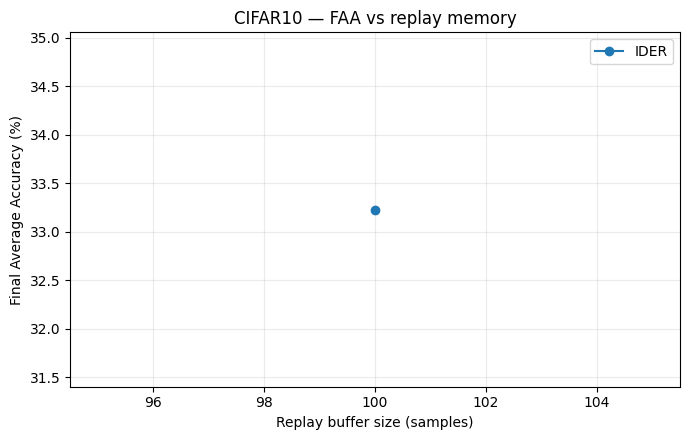

In [42]:
# Cell 42 — Accuracy vs replay-memory budget

if not agg.empty:
    for dataset_name in sorted(agg["dataset"].unique()):
        plt.figure(figsize=(7, 4.5))
        sub = agg[agg["dataset"] == dataset_name]

        for method, g in sub.groupby("method"):
            g = g.sort_values("buffer_size")
            plt.plot(
                g["buffer_size"],
                g["FAA_mean"],
                marker="o",
                label=method,
            )

        plt.xlabel("Replay buffer size (samples)")
        plt.ylabel("Final Average Accuracy (%)")
        plt.title(f"{dataset_name.upper()} — FAA vs replay memory")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

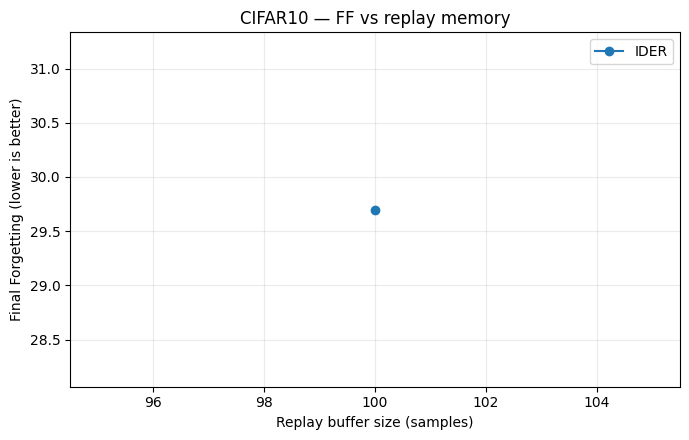

In [43]:
# Cell 43 — Forgetting vs replay-memory budget

if not agg.empty:
    for dataset_name in sorted(agg["dataset"].unique()):
        plt.figure(figsize=(7, 4.5))
        sub = agg[agg["dataset"] == dataset_name]

        for method, g in sub.groupby("method"):
            g = g.sort_values("buffer_size")
            plt.plot(
                g["buffer_size"],
                g["FF_mean"],
                marker="o",
                label=method,
            )

        plt.xlabel("Replay buffer size (samples)")
        plt.ylabel("Final Forgetting (lower is better)")
        plt.title(f"{dataset_name.upper()} — FF vs replay memory")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

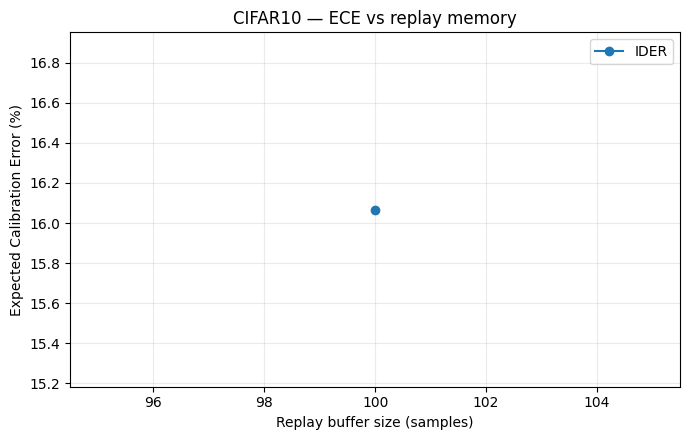

In [44]:
# Cell 44 — Calibration vs replay-memory budget

if not agg.empty:
    for dataset_name in sorted(agg["dataset"].unique()):
        plt.figure(figsize=(7, 4.5))
        sub = agg[agg["dataset"] == dataset_name]

        for method, g in sub.groupby("method"):
            g = g.sort_values("buffer_size")
            plt.plot(
                g["buffer_size"],
                g["ECE_mean"],
                marker="o",
                label=method,
            )

        plt.xlabel("Replay buffer size (samples)")
        plt.ylabel("Expected Calibration Error (%)")
        plt.title(f"{dataset_name.upper()} — ECE vs replay memory")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [45]:
# Cell 45 — Marginal memory return table

cols = [
    "method", "dataset", "buffer_size",
    "FAA_mean", "FF_mean", "ECE_mean",
    "buffer_MB",
    "memory_fraction",
    "performance_retention",
    "marginal_FAA_per_1000_samples",
    "marginal_FF_reduction_per_1000_samples",
]

if not eff.empty:
    display(eff[cols].round(4))

,method,dataset,buffer_size,FAA_mean,FF_mean,ECE_mean,buffer_MB,memory_fraction,performance_retention,marginal_FAA_per_1000_samples,marginal_FF_reduction_per_1000_samples
0,IDER,cifar10,100,33.23,29.7,16.0673,0.2937,1.0,1.0,NaN,NaN


In [46]:
# Cell 46 — Pareto analysis: memory cost vs FAA

def pareto_flag(g):
    g = g.copy()
    flags = []

    for i, r in g.iterrows():
        dominated = False

        for j, q in g.iterrows():
            if i == j:
                continue

            # q dominates r if it uses no more memory and has no lower FAA,
            # with at least one strict improvement.
            no_more_memory = q["buffer_MB"] <= r["buffer_MB"]
            no_lower_acc = q["FAA_mean"] >= r["FAA_mean"]
            strict = (
                q["buffer_MB"] < r["buffer_MB"]
                or q["FAA_mean"] > r["FAA_mean"]
            )

            if no_more_memory and no_lower_acc and strict:
                dominated = True
                break

        flags.append(not dominated)

    g["pareto_memory_vs_FAA"] = flags
    return g

if not agg.empty:
    pareto = (
        agg.groupby(["method", "dataset"], group_keys=False)
        .apply(pareto_flag, include_groups=False)
        .reset_index()
    )
    display(pareto)

,index,buffer_size,n_runs,FAA_mean,FAA_std,FF_mean,FF_std,ECE_mean,ECE_std,buffer_MB,model_MB,minutes_mean,pareto_memory_vs_FAA
0,0,100,1,33.23,NaN,29.7,NaN,16.06729,NaN,0.293732,42.630653,15.781571,True


In [47]:
# Cell 47 — Paper anchor values for context

paper_reference = pd.DataFrame([
    ["IDER", "cifar10",  200,  71.02, 1.98, 15.28, 2.41],
    ["IDER", "cifar10",  500,  74.74, 0.42, 11.93, 0.49],
    ["IDER", "cifar100", 500,  44.82, 0.85, 29.98, 2.52],
    ["IDER", "cifar100", 2000, 56.59, 0.35, 17.46, 1.04],
], columns=[
    "method", "dataset", "buffer_size",
    "paper_FAA_mean", "paper_FAA_std",
    "paper_FF_mean", "paper_FF_std",
])

display(paper_reference)

if PROFILE != "PAPER_ANCHOR":
    print(
        "NOTE: T4_MEMORY_PILOT uses fewer epochs, so these values are "
        "context only and should NOT be treated as a direct reproduction comparison."
    )

,method,dataset,buffer_size,paper_FAA_mean,paper_FAA_std,paper_FF_mean,paper_FF_std
0,IDER,cifar10,200,71.02,1.98,15.28,2.41
1,IDER,cifar10,500,74.74,0.42,11.93,0.49
2,IDER,cifar100,500,44.82,0.85,29.98,2.52
3,IDER,cifar100,2000,56.59,0.35,17.46,1.04


NOTE: T4_MEMORY_PILOT uses fewer epochs, so these values are context only and should NOT be treated as a direct reproduction comparison.


In [48]:
# Cell 48 — Compare to paper only when a matching anchor exists

if not agg.empty:
    cmp = agg.merge(
        paper_reference,
        on=["method", "dataset", "buffer_size"],
        how="left",
    )

    cmp["FAA_delta_vs_paper"] = cmp["FAA_mean"] - cmp["paper_FAA_mean"]
    cmp["FF_delta_vs_paper"] = cmp["FF_mean"] - cmp["paper_FF_mean"]
    cmp["direct_protocol_comparison"] = (PROFILE == "PAPER_ANCHOR")

    display(cmp)

,method,dataset,buffer_size,n_runs,FAA_mean,FAA_std,FF_mean,FF_std,ECE_mean,ECE_std,buffer_MB,model_MB,minutes_mean,paper_FAA_mean,paper_FAA_std,paper_FF_mean,paper_FF_std,FAA_delta_vs_paper,FF_delta_vs_paper,direct_protocol_comparison
0,IDER,cifar10,100,1,33.23,NaN,29.7,NaN,16.06729,NaN,0.293732,42.630653,15.781571,NaN,NaN,NaN,NaN,NaN,NaN,False


In [49]:
# Cell 49 — Recommend the smallest budget retaining >= 95% of largest-budget FAA

def recommended_budget(eff_df, retention_target=0.95):
    rows = []

    if eff_df.empty:
        return pd.DataFrame()

    for (method, dataset), g in eff_df.groupby(["method", "dataset"]):
        g = g.sort_values("buffer_size")
        ok = g[g["performance_retention"] >= retention_target]

        if len(ok):
            r = ok.iloc[0]
            rows.append({
                "method": method,
                "dataset": dataset,
                "retention_target": retention_target,
                "recommended_buffer": int(r["buffer_size"]),
                "FAA": float(r["FAA_mean"]),
                "FF": float(r["FF_mean"]),
                "buffer_MB": float(r["buffer_MB"]),
                "performance_retention": float(r["performance_retention"]),
            })

    return pd.DataFrame(rows)

recommendations = recommended_budget(eff, 0.95)
display(recommendations)

,method,dataset,retention_target,recommended_buffer,FAA,FF,buffer_MB,performance_retention
0,IDER,cifar10,0.95,100,33.23,29.7,0.293732,1.0


In [50]:
# Cell 50 — Export tables

if not results.empty:
    results.to_csv(OUT / "per_run_results.csv", index=False)

if not agg.empty:
    agg.to_csv(OUT / "aggregate_results.csv", index=False)

if not eff.empty:
    eff.to_csv(OUT / "memory_efficiency_results.csv", index=False)

if not recommendations.empty:
    recommendations.to_csv(
        OUT / "recommended_memory_budgets.csv",
        index=False,
    )

print("Tables exported to:", OUT)

Tables exported to: /kaggle/working/ider_memory_study


In [51]:
# Cell 51 — Lightweight archive (excludes large .pt checkpoints)

archive_dir = OUT / "_lightweight_export"

if archive_dir.exists():
    shutil.rmtree(archive_dir)

archive_dir.mkdir(parents=True, exist_ok=True)

for p in OUT.iterdir():
    if p.is_file() and p.suffix.lower() != ".pt":
        shutil.copy2(p, archive_dir / p.name)

if LIGHTWEIGHT_ZIP.exists():
    LIGHTWEIGHT_ZIP.unlink()

shutil.make_archive(
    str(LIGHTWEIGHT_ZIP.with_suffix("")),
    "zip",
    root_dir=archive_dir,
)

print("Lightweight result archive:", LIGHTWEIGHT_ZIP)
print("Rolling checkpoints remain separately in:", CKPT_DIR)

Lightweight result archive: /kaggle/working/IDER_MEMORY_STUDY_RESULTS.zip
Rolling checkpoints remain separately in: /kaggle/working/ider_memory_study/checkpoints


In [52]:
# Cell 52 — Checkpoint inventory

ckpts = sorted(CKPT_DIR.glob("ckpt_*.pt"))

print("Checkpoint count:", len(ckpts))

for p in ckpts:
    print(
        p.name,
        f"{p.stat().st_size / 1024**2:.1f} MB"
    )

Checkpoint count: 1
ckpt_ider_cifar10_b100_s0.pt 85.7 MB


## Kaggle multi-session workflow

1. Enable **Tesla T4**.
2. Keep Internet enabled the first time so CIFAR can download.
3. Run from the top through the training cell.
4. The notebook runs at most `MAX_NEW_JOBS_PER_SESSION` new jobs.
5. A rolling `.pt` checkpoint is saved after every epoch.
6. Before the Kaggle session ends, use **Save Version** so `/kaggle/working/ider_memory_study/` becomes notebook output.
7. In the next session, attach the previous notebook output as an **Input**.
8. Run from the top. The notebook merges old results and restores `ckpt_*.pt` automatically.
9. If a run stopped halfway through a task, it resumes from the next saved epoch.

### Suggested research workflow

Start with `T4_MEMORY_PILOT` and one seed. Use the memory curves to identify useful buffer budgets. Then rerun only the selected budgets with 3–5 seeds. Use `PAPER_ANCHOR` only when you specifically want the 50-epoch paper-aligned settings.

### Interpretation caution

`FAA per MB`, marginal FAA gain, marginal forgetting reduction, and the 95%-retention budget are **derived analyses**, not metrics defined by the IDER paper. Report them explicitly as memory-efficiency analyses rather than as official IDER metrics.